In [1]:
import scanpy as sc
import blend

We import the data, where adata_q represents the dataset with already identified spatial domain labels stored in adata_q.obs['BLEND'].
The dataset adata_k contains a larger collection of cells, including those from adata_q. First, we assign the labels from adata_q to adata_k, storing them in adata_k.obs['cluster'].

In [ ]:
adata_q = sc.read_h5ad('./KNN_cluster_manual/Mouse_olfa_cluster_6w.h5ad')
adata_k = sc.read_h5ad('./KNN_cluster_manual/w01_PMID_35512705_Mouse_olfa_S1_stereo_seq.h5ad')

In [3]:
adata_k.obs['cluster'] = adata_q.obs['BLEND']

In [4]:
adata_k.obs

,annotation,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,cluster
824_768_BX7_final,Cavity,68,4.234107,140.0,4.948760,0
842_564_BX7_final,SEZ,587,6.376727,1393.0,7.239933,2
996_608_BX7_final,GCL-I,679,6.522093,1749.0,7.467371,NaN
748_692_BX7_final,Cavity,98,4.595120,323.0,5.780744,11
795_659_BX7_final,Meninges,155,5.049856,321.0,5.774552,4
...,...,...,...,...,...,...
775_570_BX7_final,ML,486,6.188264,1208.0,7.097549,9
890_753_BX7_final,GCL-D,645,6.470800,1631.0,7.397562,NaN
1009_775_BX7_final,OPL,556,6.322565,1362.0,7.217443,7
977_809_BX7_final,IPL,769,6.646391,1970.0,7.586296,NaN


Next, we apply the fill_leiden_by_neighbors function from BLEND. This function uses a KNN-based approach to assign cluster labels to cells in adata_k that do not yet have labels. For example, if adata_k contains 100,000 cells in total, and only 60,000 of them already have assigned labels, the function will distribute labels to the remaining 40,000 unlabeled cells. The entire process takes only a few seconds.

In [5]:
blend.KNN_classify(adata_k, leiden_col='cluster', spatial_key='spatial', K=10)

In [6]:
adata_k.obs

,annotation,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,cluster
824_768_BX7_final,Cavity,68,4.234107,140.0,4.948760,0
842_564_BX7_final,SEZ,587,6.376727,1393.0,7.239933,2
996_608_BX7_final,GCL-I,679,6.522093,1749.0,7.467371,3
748_692_BX7_final,Cavity,98,4.595120,323.0,5.780744,11
795_659_BX7_final,Meninges,155,5.049856,321.0,5.774552,4
...,...,...,...,...,...,...
775_570_BX7_final,ML,486,6.188264,1208.0,7.097549,9
890_753_BX7_final,GCL-D,645,6.470800,1631.0,7.397562,2
1009_775_BX7_final,OPL,556,6.322565,1362.0,7.217443,7
977_809_BX7_final,IPL,769,6.646391,1970.0,7.586296,7


In [9]:
adata_k.obs['cluster'].isna().sum()

np.int64(4)

Finally, the results after label assignment for the full dataset adata_k are visualized.

In [7]:
sc.pp.normalize_total(adata_k, target_sum=1e4)
sc.pp.log1p(adata_k)
sc.pp.highly_variable_genes(adata_k)
adata_k = adata_k[:, adata_k.var.highly_variable]
sc.pp.scale(adata_k, max_value=10)
sc.tl.pca(adata_k, svd_solver='arpack')
sc.pp.neighbors(adata_k, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata_k)

/home/lixuan/miniconda3/envs/blend_demo/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


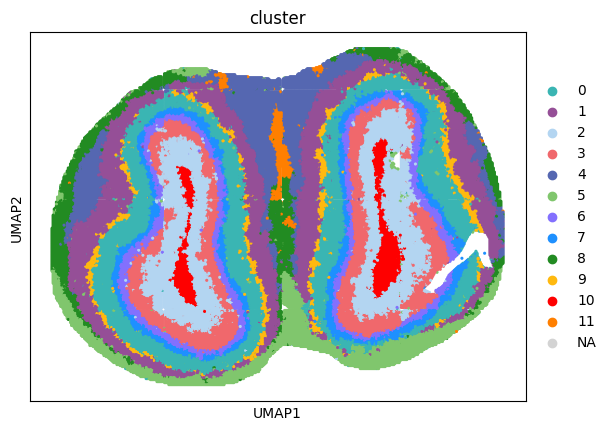

In [8]:
custom_colors = ['#3ab5b3','#954f97','#b3d5f1','#f0686c','#5567b1','#80c66d','#8370fe','#1e90ff','#228b22','#ffb90f','#fe0000','#ff7f00','#8b864e','#eaf0b2','#f7d8d6','#c4c2da','#8a8a88','#d8a266','#b86078',
                 '#39b086',"#3467a1","#345201","#ebe5c2", "#D57358", "#023047", "#F7CA71", "#1697a6", "#8bc6cc", "#C9DEC3","#169820"]
adata_k.obsm['X_umap'] = adata_k.obsm['spatial']
sc.pl.umap(adata_k, color=['cluster'], palette=custom_colors, legend_loc='right margin', size=20)